# ARMA(1,1) Model with `numpyro_forecast`

This notebook ports the blog post [**Notes on an ARMA(1,1) Model with NumPyro**](https://juanitorduz.github.io/arma_numpyro/) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. Autoregressive moving average (ARMA) models are the workhorse of classical time series analysis, and the $(1,1)$ member is the smallest one that combines both mechanisms: an autoregressive term that feeds the previous *observation* back into the mean, and a moving average term that feeds the previous *forecast error* back. We simulate data from an ARMA(1,1) process, so we own the data generating process and can verify that the model recovers the true parameters, and we fit it with MCMC (the NUTS sampler) through the package's functional `fit_mcmc`.

Two deliberate changes from the blog post are worth calling out:

- Instead of a single train-test split, we evaluate with **expanding-window time-slice cross-validation** via `numpyro_forecast.backtest`, scoring every fold with the continuous ranked probability score (CRPS) and the empirical coverage of the central $50\%$ and $94\%$ intervals, both in-sample and out-of-sample, exactly as in the [univariate forecasting example](https://juanitorduz.github.io/numpyro_forecast/examples/forecasting_univariate.html).
- The forecast path is fully **generative**: over the horizon we sample future innovations and feed them back into the ARMA recursion, so the forecast uncertainty compounds correctly step by step. The blog post instead zeroed the future errors inside its prediction loop, which understates the multi-step uncertainty.

A practical note on the design, in the same spirit as the [exponential smoothing example](https://juanitorduz.github.io/numpyro_forecast/examples/exponential_smoothing_state_space.html): the built-in `time_series` and `predict` primitives assume a deterministic mean plus independent per-step noise, which cannot express ARMA's recursive dependence on past observations and errors. We therefore write the model body directly against the functional API's `Horizon` value, registering the framework's `"obs"` and `"forecast"` sites ourselves, while reusing everything downstream: `fit_mcmc`, `to_datatree`, and `backtest`. And since an ARMA model is, at heart, a regression on the *lagged series itself*, the observed series plays the role of the covariates: the `covariates` argument is the natural carrier for the history the filter needs, because it spans the full horizon and is available at prediction time. The model only ever reads the first `t_obs` rows, so no future information leaks into a forecast (we simply never look past the training window).

## Prepare notebook

In [1]:
from functools import partial

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
from jax import random
from jaxtyping import Float

from numpyro_forecast import (
    HMCForecaster,
    backtest,
    eval_coverage,
    eval_crps,
    forecasting_model,
    predictions_to_datatree,
    to_datatree,
)
from numpyro_forecast.acf import acf, pacf
from numpyro_forecast.functional import Horizon, fit_mcmc
from numpyro_forecast.typing import Array

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)


%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Generate data

The ARMA(1,1) process is defined by the recursion

$$y_t = \phi \, y_{t-1} + \theta \, \varepsilon_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \text{Normal}(0, \sigma),$$

where $\phi$ is the autoregressive coefficient, $\theta$ the moving average coefficient, and $\sigma$ the innovation scale. We simulate $T = 100$ observations with $\phi = 0.4$, $\theta = 0.7$, and $\sigma = 0.5$ (one extra step initializes the recursion and is dropped). As in the blog post, we write the simulation twice: first as a transparent Python loop, then with [`jax.lax.scan`](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html), which compiles the recursion into a single efficient operation and is the idiom we also use inside the model. Compared to the blog we tighten the type hints: the key takes the package-wide `Array` type and the return shape is spelled out with a [jaxtyping](https://docs.kidger.site/jaxtyping/) annotation.

In [2]:
phi_true = 0.4
theta_true = 0.7
noise_scale = 0.5
n_samples = 100 + 1  # one extra step to initialize the recursion


def generate_arma_1_1_data_for_loop(
    rng_key: Array, n_samples: int, phi: float, theta: float, noise_scale: float
) -> Float[Array, " t"]:
    """Simulate an ARMA(1,1) series with an explicit Python loop.

    Parameters
    ----------
    rng_key
        PRNG key for the innovations.
    n_samples
        Number of steps to simulate; the initial step is dropped, so the
        returned series has ``n_samples - 1`` entries.
    phi
        Autoregressive coefficient.
    theta
        Moving average coefficient.
    noise_scale
        Scale of the Gaussian innovations.

    Returns
    -------
    Float[Array, " t"]
        The simulated series of length ``n_samples - 1``.
    """
    error = noise_scale * random.normal(rng_key, (n_samples,))
    y = jnp.zeros(n_samples)
    for t in range(1, n_samples):
        y = y.at[t].set(phi * y[t - 1] + theta * error[t - 1] + error[t])
    return y[1:]


rng_key, rng_subkey = random.split(rng_key)
y_for_loop = generate_arma_1_1_data_for_loop(
    rng_subkey, n_samples, phi_true, theta_true, noise_scale
)
print(f"series shape: {y_for_loop.shape}")

series shape: (100,)


The scan version threads a carry `(y_prev, error_prev)` through the innovations and produces the same series. Because JAX keys are pure, reusing `rng_subkey` reproduces the innovations bit for bit, so we can also print their realized standard deviation: with only $T = 100$ draws it lands visibly below the population value $\sigma = 0.5$, a fact we will need when judging the parameter recovery below.

In [3]:
def generate_arma_1_1_data_scan(
    rng_key: Array, n_samples: int, phi: float, theta: float, noise_scale: float
) -> Float[Array, " t"]:
    """Simulate an ARMA(1,1) series with :func:`jax.lax.scan`.

    Parameters
    ----------
    rng_key
        PRNG key for the innovations.
    n_samples
        Number of steps to simulate; the initial step is dropped, so the
        returned series has ``n_samples - 1`` entries.
    phi
        Autoregressive coefficient.
    theta
        Moving average coefficient.
    noise_scale
        Scale of the Gaussian innovations.

    Returns
    -------
    Float[Array, " t"]
        The simulated series of length ``n_samples - 1``.
    """
    error = noise_scale * random.normal(rng_key, (n_samples,))

    def arma_step(carry, noise):
        y_prev, error_prev = carry
        y_t = phi * y_prev + theta * error_prev + noise
        return (y_t, noise), y_t

    _, y = jax.lax.scan(arma_step, (jnp.zeros(()), error[0]), error[1:])
    return y


y = generate_arma_1_1_data_scan(rng_subkey, n_samples, phi_true, theta_true, noise_scale)
print(f"for-loop and scan agree: {jnp.allclose(y_for_loop, y, atol=1e-6)}")

eps_realized = noise_scale * random.normal(rng_subkey, (n_samples,))
print(f"realized innovation sd: {eps_realized.std():.2f} (population value: {noise_scale})")

for-loop and scan agree: True
realized innovation sd: 0.43 (population value: 0.5)


Throughout the package, time lives at axis `-2` and the observation dimension at axis `-1`, so the single series has shape `(100, 1)`. Following the design note above, the same array also serves as the covariates.

data shape: (100, 1)


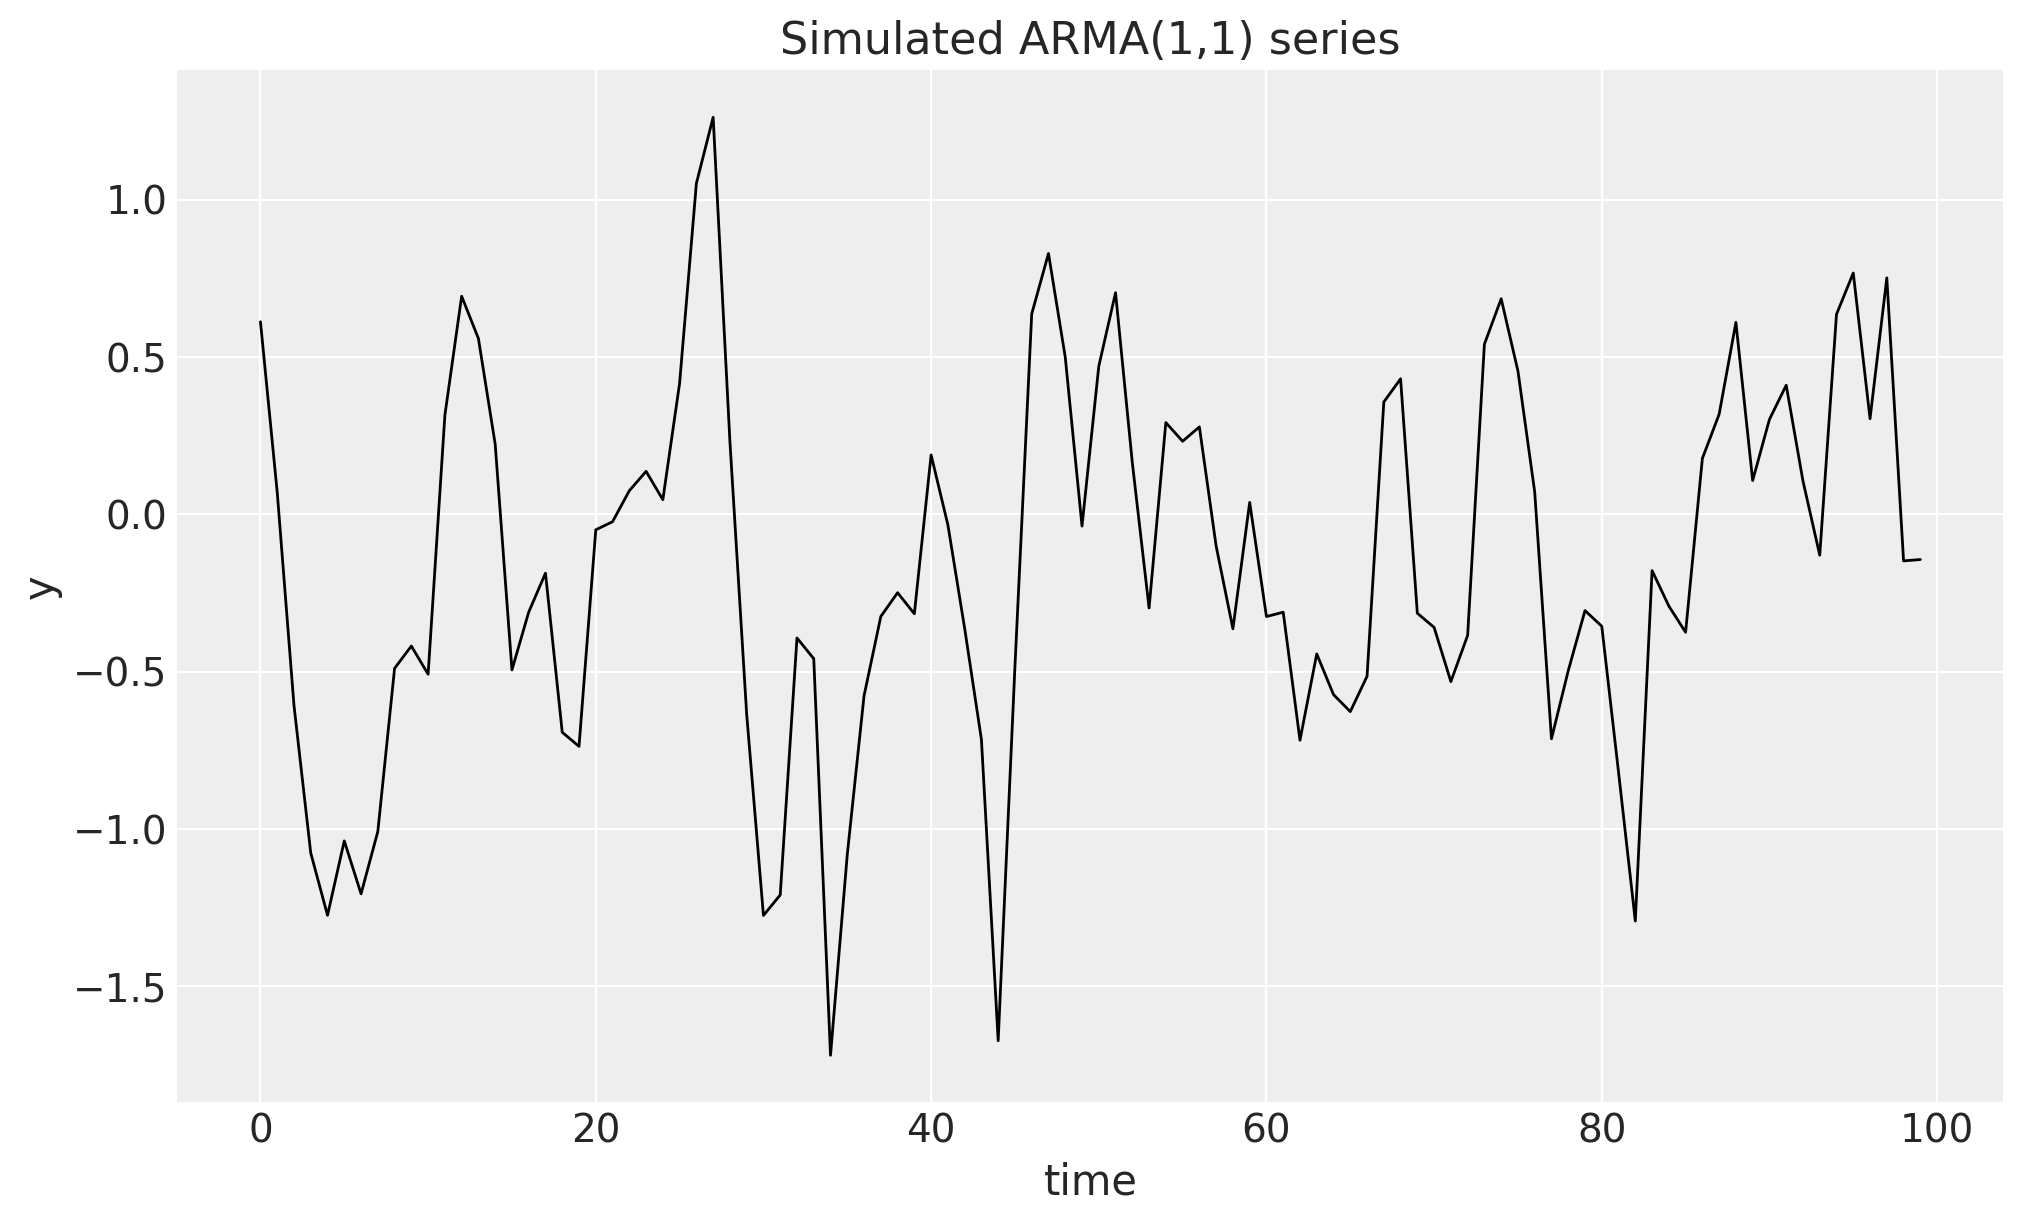

In [4]:
data = y[:, None]
covariates = data  # the lagged series is the "covariate" of an ARMA model
duration = data.shape[-2]
time = np.arange(duration)
print(f"data shape: {data.shape}")

fig, ax = plt.subplots()
ax.plot(time, y, color="black", lw=1)
ax.set(title="Simulated ARMA(1,1) series", xlabel="time", ylabel="y");

## ACF and PACF

Before modeling, we look at the empirical autocorrelation function (ACF) and partial autocorrelation function (PACF), the classical tools for identifying ARMA orders. The blog post used the statsmodels plotting helpers; here we use the package's own [`acf`](https://juanitorduz.github.io/numpyro_forecast/reference/acf.acf.html) and [`pacf`](https://juanitorduz.github.io/numpyro_forecast/reference/acf.pacf.html) functions from `numpyro_forecast.acf`. Both are jitted, compute the ACF for all lags at once via the FFT, derive the PACF through the Durbin-Levinson recursion, and broadcast over leading batch axes, so the same call works on a panel of series (with time on the last axis).

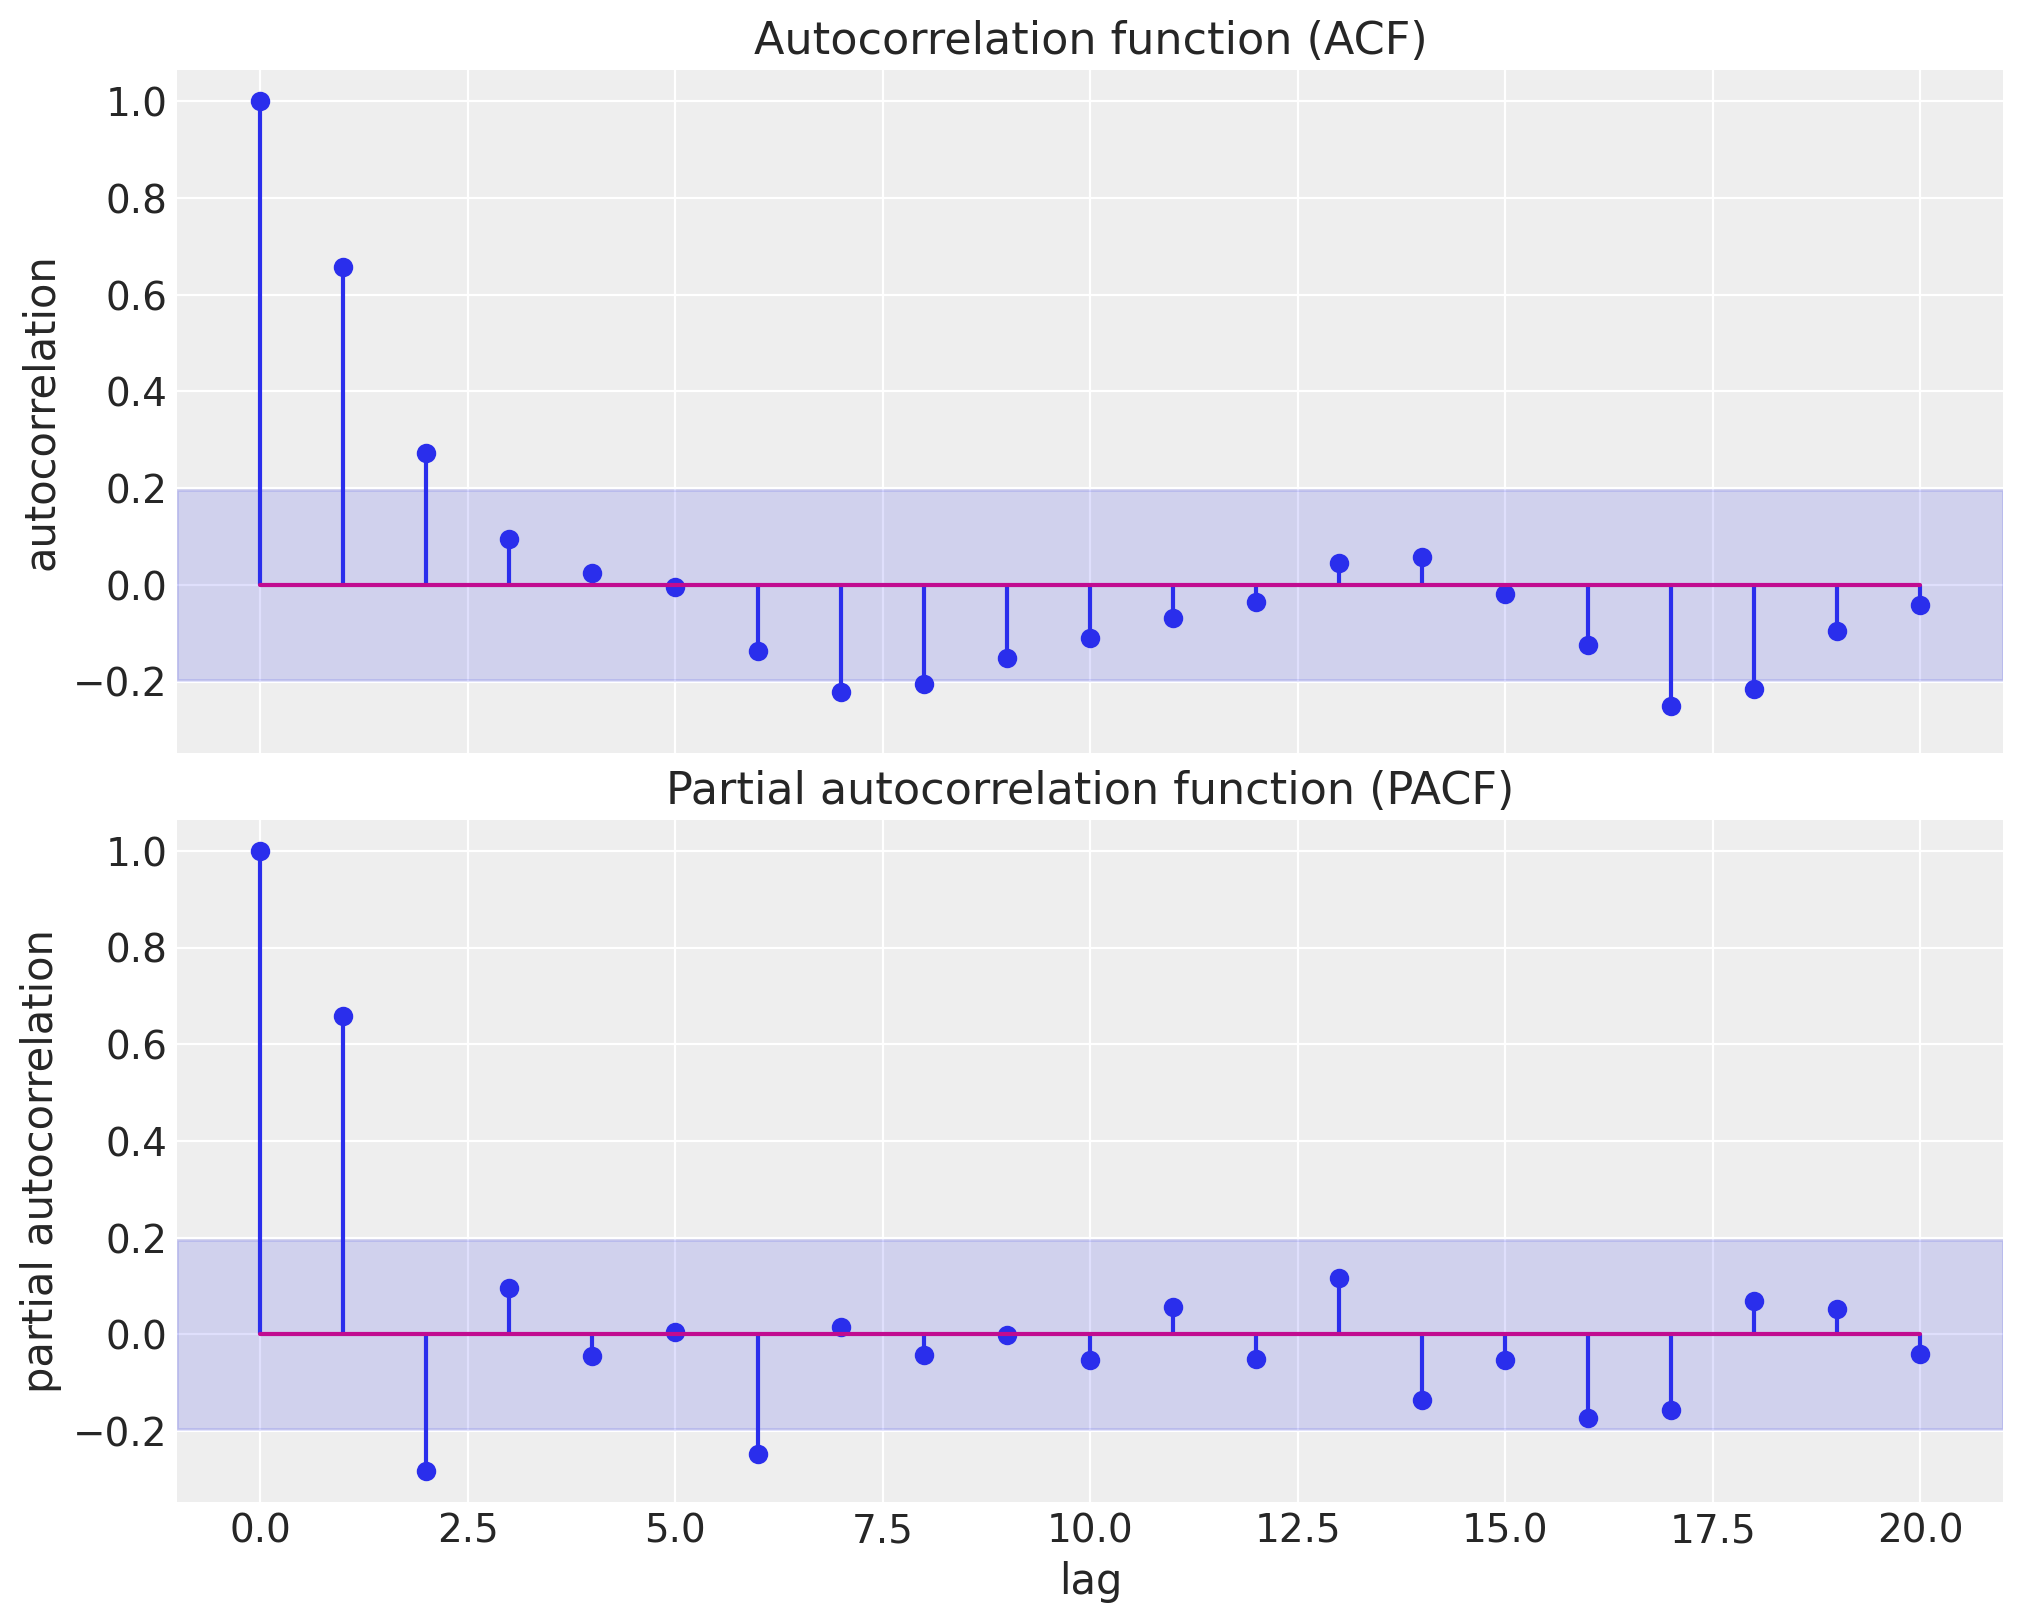

In [5]:
max_lag = 20
lags = np.arange(max_lag + 1)
significance_bound = 1.96 / np.sqrt(duration)

fig, (ax_acf, ax_pacf) = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 8), sharex=True, sharey=True, layout="constrained"
)
ax_acf.stem(lags, np.asarray(acf(y, max_lag)))
ax_acf.axhspan(-significance_bound, significance_bound, color="C0", alpha=0.15)
ax_acf.set(title="Autocorrelation function (ACF)", ylabel="autocorrelation")
ax_pacf.stem(lags, np.asarray(pacf(y, max_lag)))
ax_pacf.axhspan(-significance_bound, significance_bound, color="C0", alpha=0.15)
ax_pacf.set(
    title="Partial autocorrelation function (PACF)",
    xlabel="lag",
    ylabel="partial autocorrelation",
);

The shaded band is the approximate $95\%$ significance region $\pm 1.96 / \sqrt{T}$ for white noise. The ACF starts high and decays geometrically over the first few lags, while the PACF is large and positive at lag $1$ and then flips to a significant negative value at lag $2$ before dying out: a sign-alternating decay rather than a clean cutoff. Neither function cuts sharply, which is the classical signature of a mixed ARMA process: a pure AR($p$) model would cut the PACF after lag $p$, and a pure MA($q$) model would cut the ACF after lag $q$.

## Model specification

The generative model adds a global mean $\mu$ to the recursion and uses the same priors as the blog post:

$$y_t = \mu + \phi \, y_{t-1} + \theta \, \varepsilon_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \text{Normal}(0, \sigma),$$

\begin{align*}
\mu & \sim \text{Normal}(0, 1), \\
\phi & \sim \text{Uniform}(-1, 1), \\
\theta & \sim \text{Uniform}(-1, 1), \\
\sigma & \sim \text{HalfNormal}(1).
\end{align*}

The key insight (from the blog post, and the same one behind the innovations state space form of exponential smoothing) is that *in sample the errors are deterministic* given the parameters and the observed data: running the recursion forward, the one-step-ahead prediction at time $t$ is $\hat{y}_t = \mu + \phi \, y_{t-1} + \theta \, \varepsilon_{t-1}$ and the error is simply $\varepsilon_t = y_t - \hat{y}_t$, initialized with $y_{-1} = \mu$ and $\varepsilon_{-1} = 0$. The whole in-sample likelihood is then a single Gaussian observation site: conditioning $y_t \sim \text{Normal}(\hat{y}_t, \sigma)$ is exactly the blog post's "condition on the errors" trick, $\varepsilon_t \sim \text{Normal}(0, \sigma)$, since the two differ only by a location shift.

The model body follows the package's two-scan pattern:

1. **In sample.** A deterministic `jax.lax.scan` filters the observed series into one-step-ahead means $\hat{y}_t$ (exposed as the deterministic site `"mu_t"`), and the `"obs"` site conditions the data on them.
2. **Out of sample.** When `h.future > 0` we draw the horizon innovations from the prior at a separate `"eps_future"` site, then roll the recursion forward feeding the *sampled* observation and innovation back into the carry, and expose the trajectory as the deterministic `"forecast"` site the forecaster reads. Because `"eps_future"` does not exist while training, `Predictive` draws it from the prior at forecast time, so the forecast uncertainty compounds over the horizon exactly as the generative process says it should.

Neither scan body contains a sample site, so plain `jax.lax.scan` is all we need.

In [6]:
def arma_1_1(h: Horizon, covariates: Array) -> None:
    """ARMA(1,1) model with a deterministic in-sample error-feedback filter.

    Parameters
    ----------
    h
        The train/forecast horizon for the current model call.
    covariates
        The observed series itself, with time at axis ``-2``; only the first
        ``h.t_obs`` rows are read.
    """
    y = covariates[..., : h.t_obs, 0]  # observed history only; never reads beyond t_obs

    mu = numpyro.sample("mu", dist.Normal(loc=0, scale=1))
    phi = numpyro.sample("phi", dist.Uniform(low=-1, high=1))
    theta = numpyro.sample("theta", dist.Uniform(low=-1, high=1))
    sigma = numpyro.sample("sigma", dist.HalfNormal(scale=1))

    def transition_fn(carry, y_t):
        y_prev, error_prev = carry
        pred = mu + phi * y_prev + theta * error_prev
        return (y_t, y_t - pred), pred

    init_carry = (mu, jnp.zeros(()))  # y_{-1} = mu and eps_{-1} = 0 seed the recursion
    (_, error_last), preds = jax.lax.scan(transition_fn, init_carry, y)

    numpyro.deterministic("mu_t", preds[:, None])
    numpyro.sample("obs", dist.Normal(loc=preds[:, None], scale=sigma), obs=h.data)

    if h.future > 0:
        eps_future = numpyro.sample(
            "eps_future", dist.Normal(loc=0, scale=sigma).expand([h.future]).to_event(1)
        )

        def forecast_fn(carry, eps):
            y_prev, error_prev = carry
            pred = mu + phi * y_prev + theta * error_prev
            y_next = pred + eps  # the sampled innovation is fed back into the carry
            return (y_next, eps), y_next

        _, y_future = jax.lax.scan(forecast_fn, (y[-1], error_last), eps_future)
        numpyro.deterministic("forecast", y_future[:, None])


model = forecasting_model(arma_1_1)

## Inference with NUTS

We fit the model on the **full series** (no train-test split; the held-out evaluation comes from the cross-validation below) with the No-U-Turn Sampler through the functional [`fit_mcmc`](https://juanitorduz.github.io/numpyro_forecast/reference/functional.mcmc.fit_mcmc.html), running $4$ chains of $1{,}000$ warmup and $1{,}000$ sampling steps each. The posterior is tiny: because the in-sample errors are deterministic, the only latent parameters are $\mu$, $\phi$, $\theta$, and $\sigma$.

We then export the whole fit into an ArviZ-schema `xarray.DataTree` with [`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html): a single call restores the `(chain, draw)` structure of the posterior draws, samples the in-sample one-step-ahead posterior predictive, and stores the observed data and covariates alongside, so everything downstream (diagnostics, trace plots, the in-sample fit) reads from one object. Since `covariates` has the same duration as `data`, there is no forecast horizon and hence no forecast groups here; the out-of-sample story comes from the cross-validation below.

In [7]:
rng_key, rng_subkey = random.split(rng_key)
fit = fit_mcmc(
    rng_subkey,
    model,
    data,
    covariates,
    num_warmup=1_000,
    num_samples=1_000,
    num_chains=4,
)

rng_key, rng_subkey = random.split(rng_key)
tree = to_datatree(
    rng_subkey,
    fit,
    model,
    data,
    covariates,
    posterior_dims={"mu_t": ["time", "obs_dim"]},
)
tree

<xarray.DataTree>
Group: /
│   Attributes:
│       inference_library:  numpyro
│       creation_library:   numpyro_forecast
│       sample_dims:        ['chain', 'draw']
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 1000, time: 100, obs_dim: 1)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           mu       (chain, draw) float32 16kB -0.09647 -0.02102 ... 0.0329 0.04597
│           mu_t     (chain, draw, time, obs_dim) float32 2MB -0.1546 0.5496 ... -0.4146
│           phi      (chain, draw) float32 16kB 0.6022 0.408 0.4649 ... 0.3659 0.1668
│           sigma    (chain, draw) float32 16kB 0.4242 0.4562 0.3988 ... 0.501 0.408
│           theta    (chain, draw) float32 16kB 0.3627 0.5471 0.3764 ... 0.5953 0.6119
│       Attributes:
│           created_at:                 2026-07-17T08:59:11.803187+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /posterior_predictive
│       Dimensions:  (chain: 4, draw: 1000, time: 100, obs_dim: 1)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (chain, draw, time, obs_dim) float32 2MB 0.378 0.03782 ... -0.08186
│       Attributes:
│           created_at:                 2026-07-17T08:59:11.929615+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (time: 100, obs_dim: 1)
│       Coordinates:
│         * time     (time) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (time, obs_dim) float32 400B 0.6115 0.06982 ... -0.1484 -0.1441
│       Attributes:
│           created_at:                 2026-07-17T08:59:11.929833+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
└── Group: /constant_data
        Dimensions:        (time: 100, covariate_dim: 1)
        Coordinates:
          * time           (time) int64 800B 0 1 2 3 4 5 6 7 ... 92 93 94 95 96 97 98 99
          * covariate_dim  (covariate_dim) int64 8B 0
        Data variables:
            covariates     (time, covariate_dim) float32 400B 0.6115 0.06982 ... -0.1441
        Attributes:
            created_at:                 2026-07-17T08:59:11.929990+00:00
            creation_library:           ArviZ
            creation_library_version:   1.2.0
            creation_library_language:  Python
            sample_dims:                []

## Diagnostics and parameter recovery

The tree's `posterior` group carries the draws with their `(chain, draw)` structure (deterministic sites such as `"mu_t"` ride along; we summarize just the four parameters), so `az.summary` gives us the whole convergence and recovery picture in one call: posterior means and standard deviations, the $94\%$ HDIs, bulk and tail effective sample sizes, $\hat{R}$, and the Monte Carlo standard errors. Since we simulated the data ourselves, we prepend the true parameter values as the first column.

In [8]:
scalar_vars = ["mu", "phi", "theta", "sigma"]
true_values = {"mu": 0.0, "phi": phi_true, "theta": theta_true, "sigma": noise_scale}

recovery = az.summary(tree, var_names=scalar_vars, ci_kind="hdi", ci_prob=0.94)
recovery.insert(0, "true_value", pd.Series(true_values))
recovery

,true_value,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.0,-0.081,0.07,-0.22,0.046,2796,2133,1.00,0.0013,0.00095
phi,0.4,0.369,0.144,0.083,0.62,2016,2108,1.00,0.0033,0.0023
theta,0.7,0.532,0.15,0.25,0.8,1994,1819,1.00,0.0033,0.0021
sigma,0.5,0.436,0.0314,0.38,0.5,3077,2811,1.00,0.00057,0.00041


The sampler recovers the parameters well: every true value lies within about two posterior standard deviations of its posterior mean, the $\hat{R}$ values are essentially $1$, and the effective sample sizes are healthy. The point estimates for $\theta$ and $\sigma$ come in somewhat low, and this is a feature of the particular realization rather than of the model: the innovations drawn for this seed happen to have a sample standard deviation of $0.43$ (against the population value $0.5$; we printed the realized value right after generating the data), and the posterior mean of $\sigma$ matches that realized scale almost exactly. The moving average coefficient is in turn the hardest parameter to pin down with $T = 100$ observations, because $\phi$ and $\theta$ can partially substitute for each other in an ARMA likelihood (a well-known feature), so its posterior is wide. The trace plots make the recovery visual: the dashed black lines mark the true values, and the chains mix well around them.

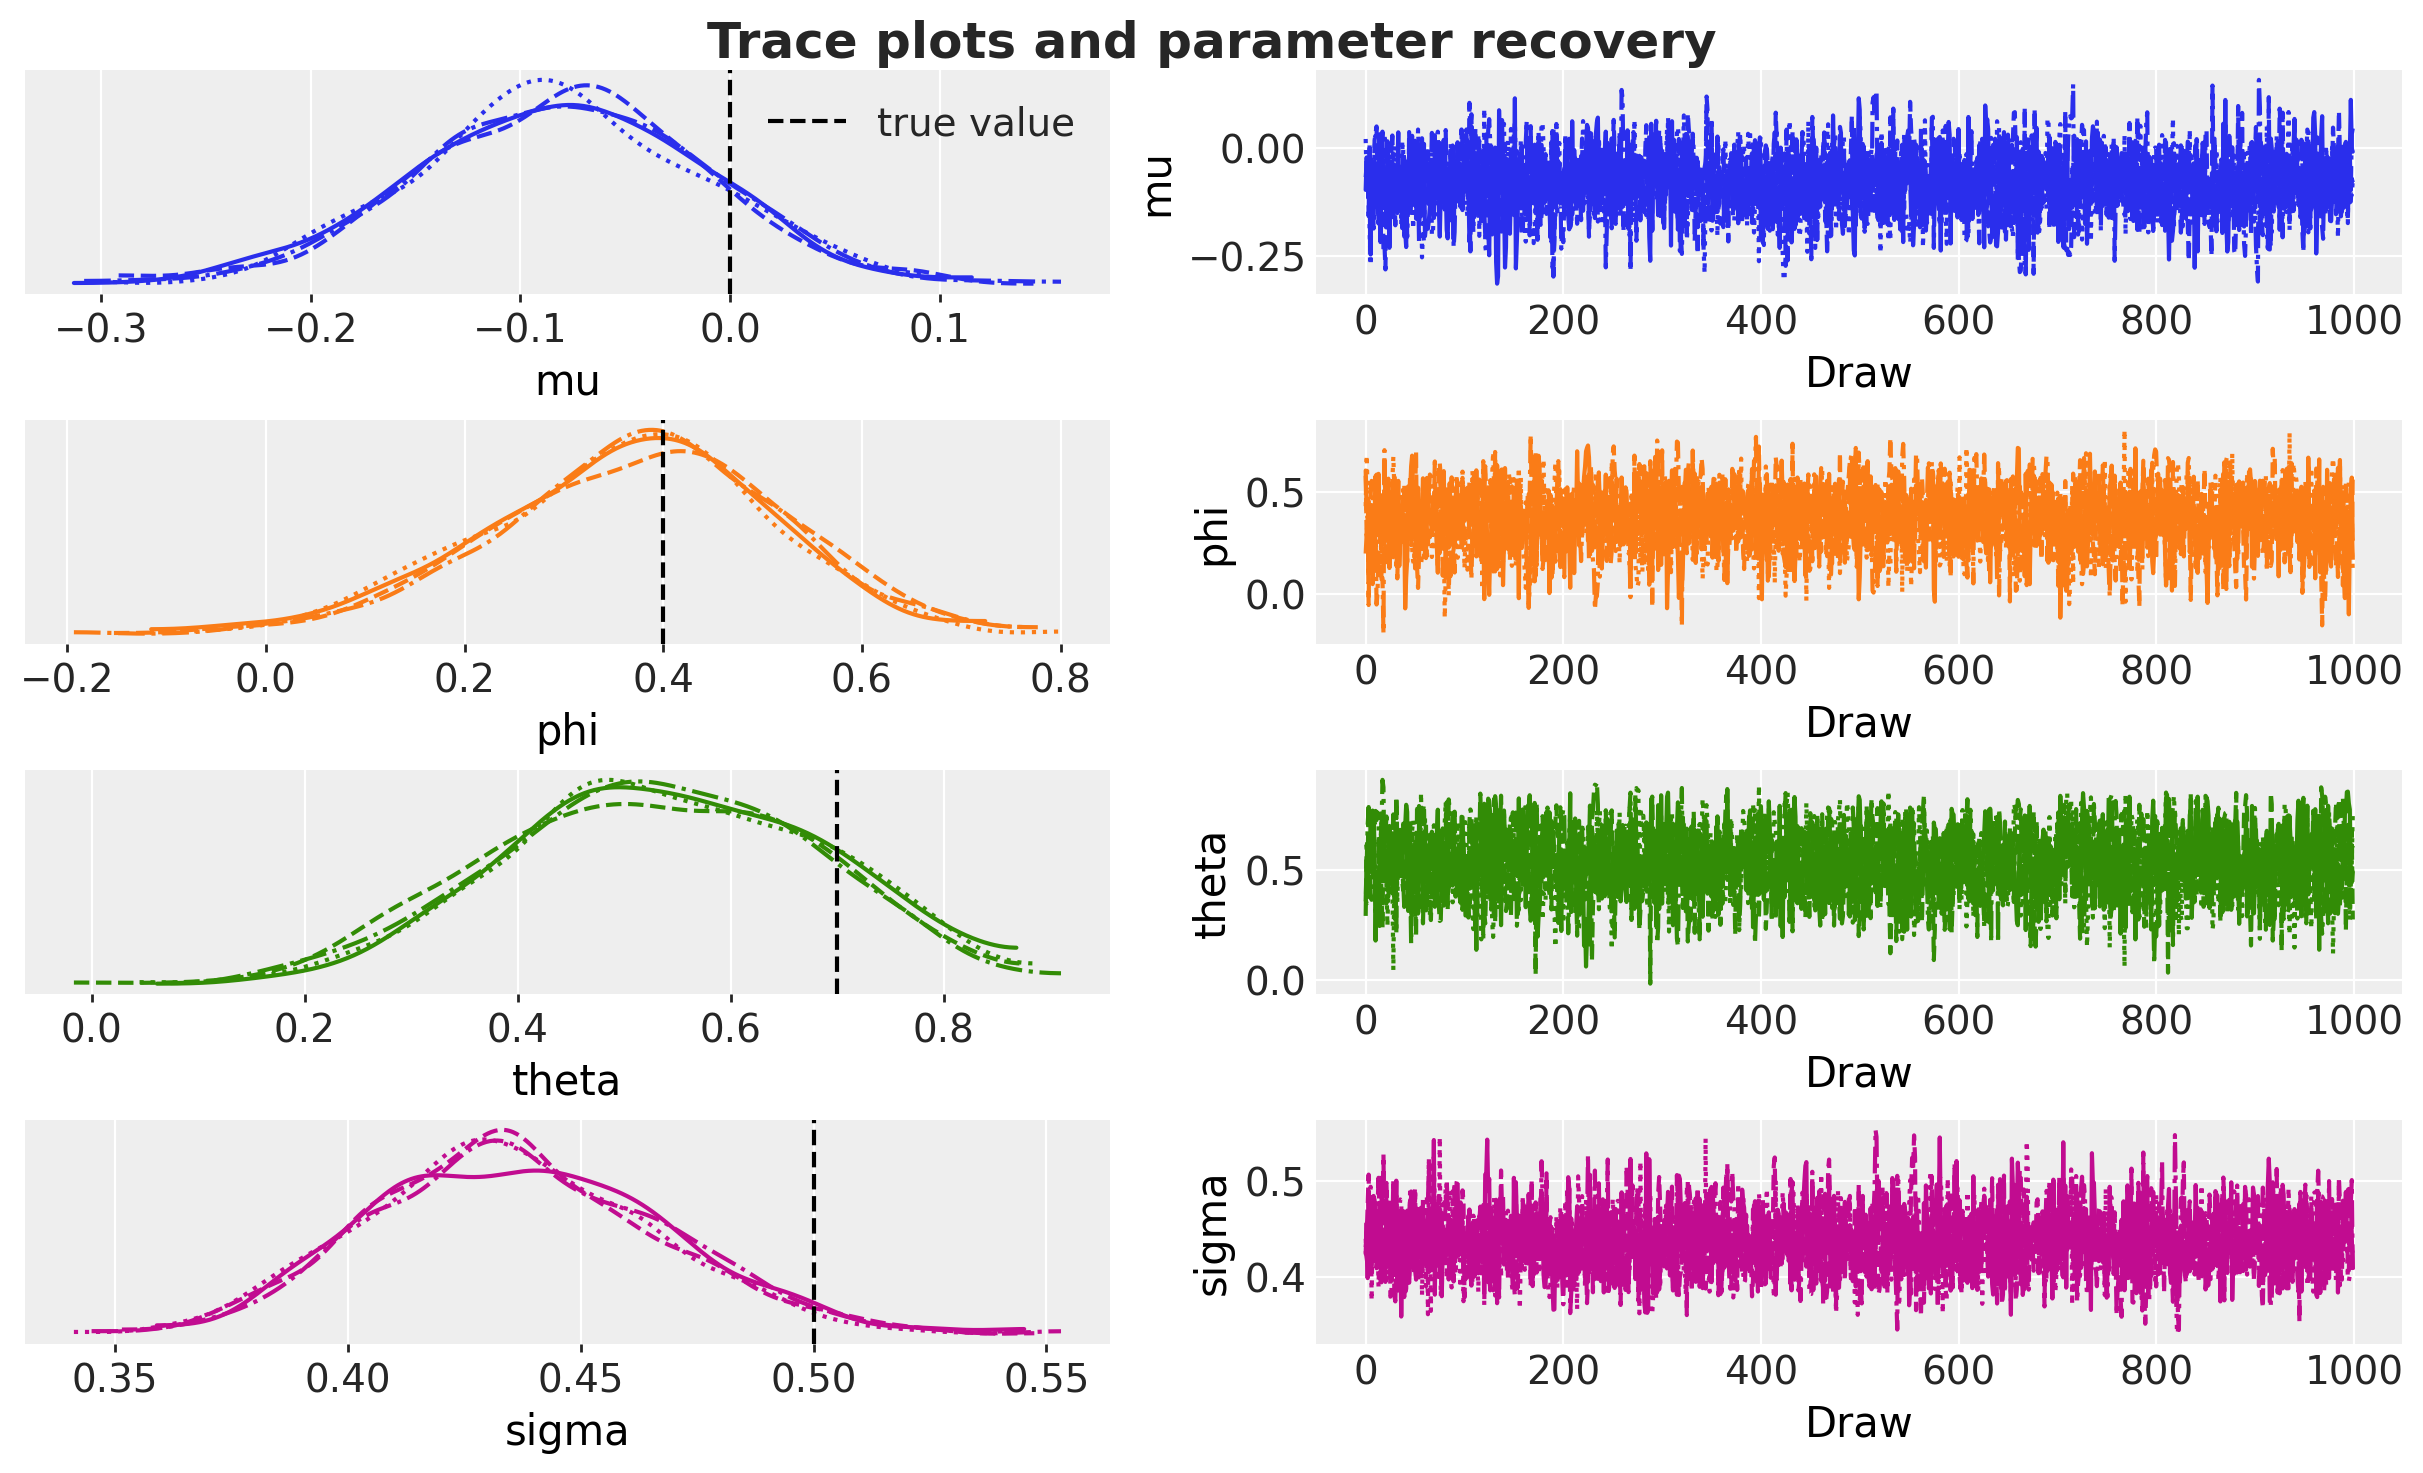

In [9]:
pc_trace = az.plot_trace_dist(
    tree,
    var_names=scalar_vars,
    compact=True,
    figure_kwargs={"figsize": (12, 7)},
)
for var_name in scalar_vars:
    ax_dist = pc_trace.viz["plot"][var_name].sel(column="dist").item()
    ax_dist.axvline(true_values[var_name], color="black", ls="--", lw=1.5, label="true value")
pc_trace.viz["plot"]["mu"].sel(column="dist").item().legend(loc="upper right")
pc_trace.viz["figure"].item().suptitle(
    "Trace plots and parameter recovery",
    fontsize=18,
    fontweight="bold",
    y=1.03,
);

## In-sample fit

Next we look at the one-step-ahead posterior predictive over the training window, which `to_datatree` already sampled into the tree's `posterior_predictive` group: at each time step the predicted mean uses the observed history up to the previous step, and the `"obs"` site adds the observation noise. We only need to stack the chains back into a single sample dimension to get the draws-first layout the plotting and scoring helpers expect. We plot the posterior mean prediction together with the $50\%$ and $94\%$ HDI bands (inner band darker, outer band lighter) against the observed series with ArviZ `plot_lm`, packing the draws with the package's `predictions_to_datatree`, and score the fit with the CRPS, a proper scoring rule that compares each observation to the whole predictive distribution (lower is better).

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


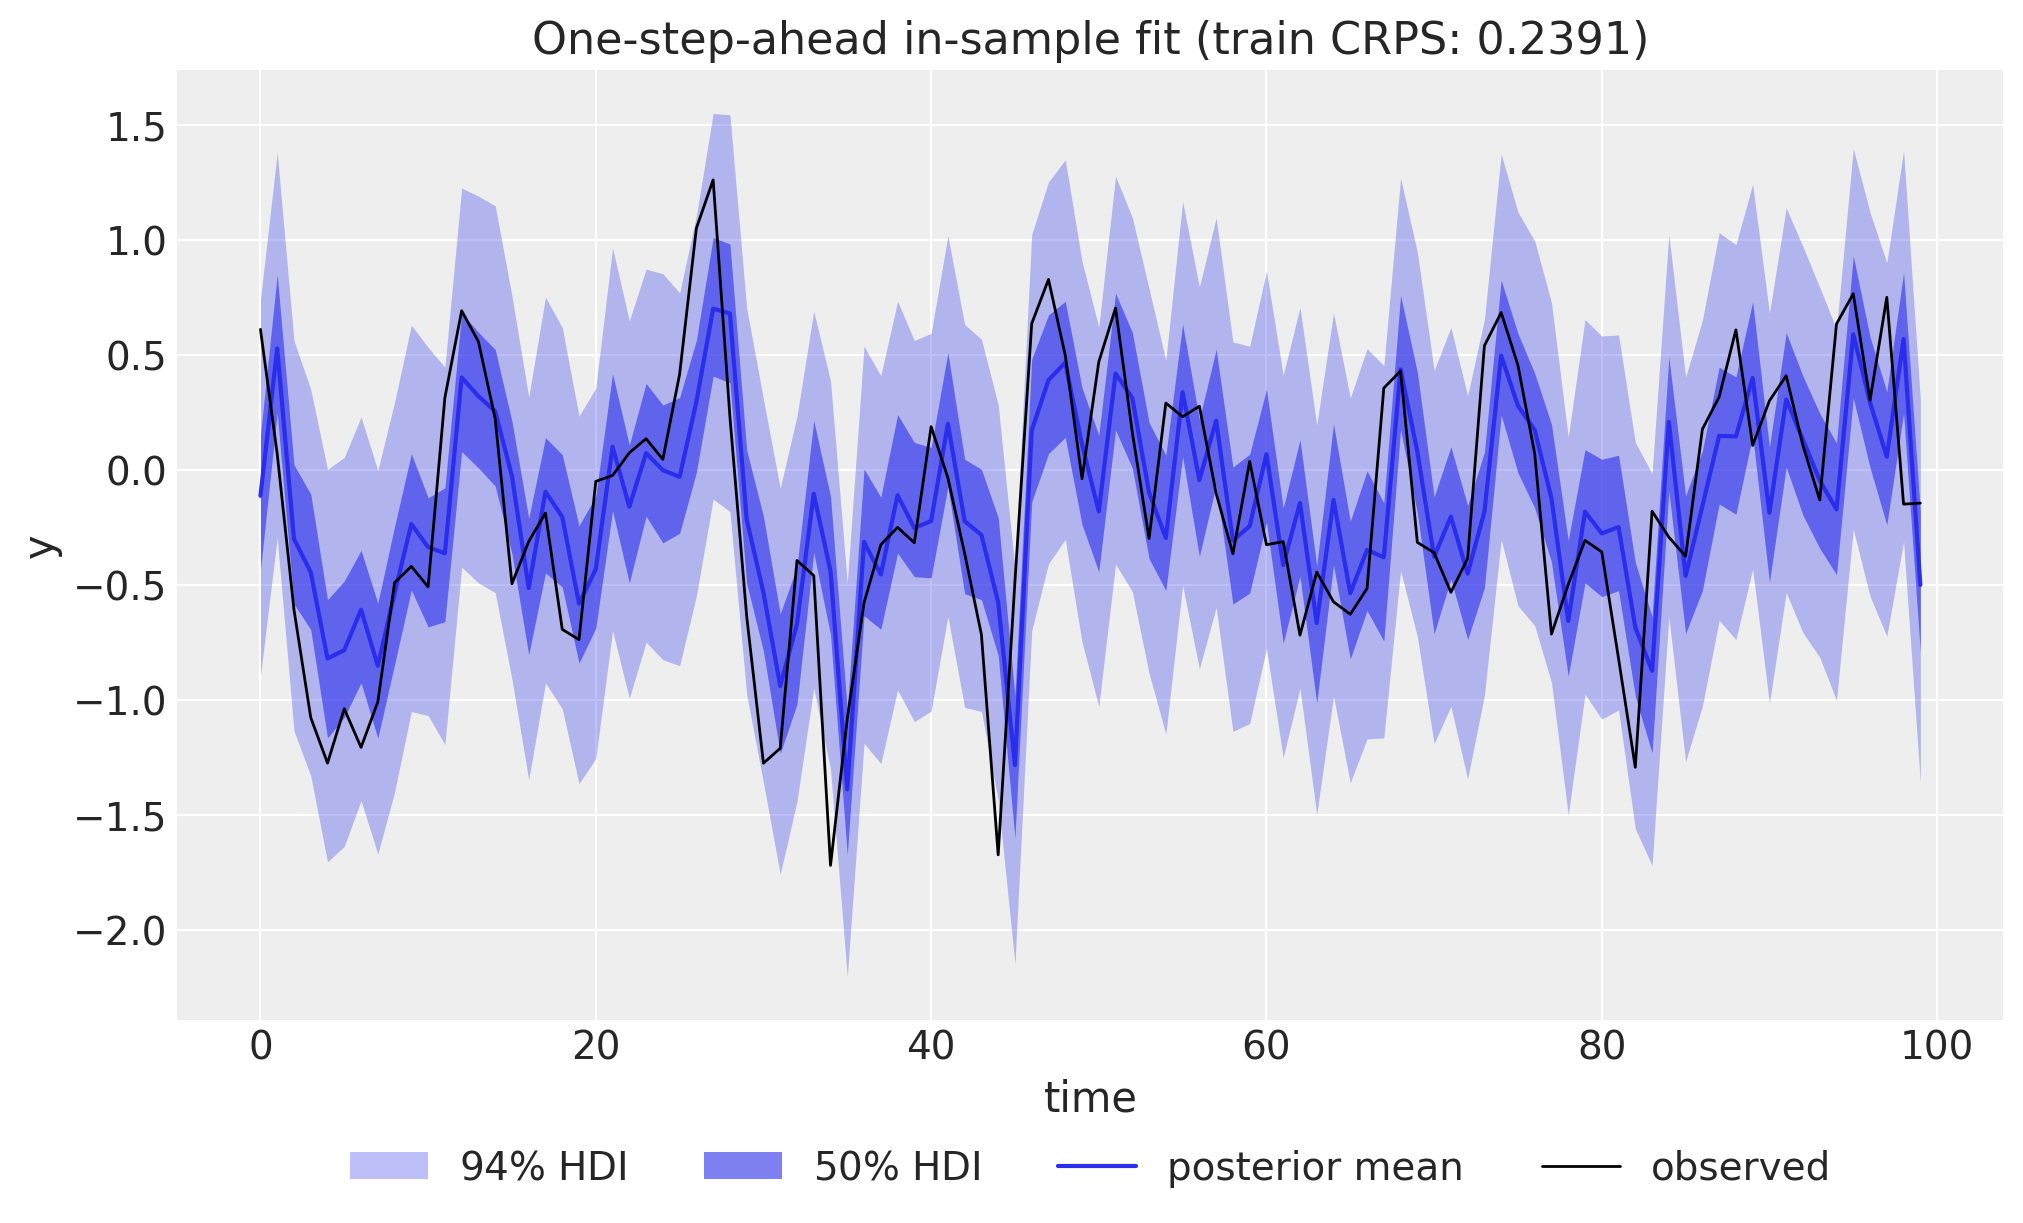

In [10]:
def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


hdi_probs = (0.5, 0.94)
hdi_alphas = [0.6, 0.3]  # 50% band darker, 94% band lighter

train_pp = (
    tree["posterior_predictive"]
    .dataset["obs"]
    .stack(sample=("chain", "draw"))
    .transpose("sample", "time", "obs_dim")
    .to_numpy()
)
crps_train = eval_crps(train_pp, data)

idata_in_sample = predictions_to_datatree(train_pp, time.astype(float), ["y"], observed=data)
pc = az.plot_lm(
    idata_in_sample,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": {"color": "C0", "alpha": 1.0, "width": 1.5},
    },
    aes={"alpha": ["prob"]},
    alpha=hdi_alphas,
    figure_kwargs={"figsize": (10, 6)},
)
bands = pc.viz["ci_band"]["t"]
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(hdi_label(0.94))
band_50.set_label(hdi_label(0.5))
pe_line = pc.viz["pe_line"]["t"].item()
pe_line.set_label("posterior mean")
ax = pc.viz["figure"].item().axes[0]
(obs_line,) = ax.plot(time, np.asarray(y), color="black", lw=1, label="observed")
ax.legend(
    handles=[band_94, band_50, pe_line, obs_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
)
ax.set(
    title=f"One-step-ahead in-sample fit (train CRPS: {crps_train:.4f})",
    xlabel="time",
    ylabel="y",
);

## Expanding-window cross-validation

A single split tells us how the model does on one held-out window. A more honest picture comes from *expanding-window* time-slice cross-validation: we repeatedly move the train/test boundary forward, refit from scratch, and forecast the next window, so every later part of the series is scored out-of-sample exactly once. `numpyro_forecast.backtest` runs this loop for us, refitting the NUTS sampler on each fold through `HMCForecaster`, the OOP counterpart of `fit_mcmc` that `backtest` constructs per fold.

We size the folds at roughly $10\%$ of the series: each fold forecasts the next `10` steps (`test_window=10`), stepping forward `10` steps at a time (`stride=10`) so the folds do not overlap, and the first `50` observations (half the series) seed the initial training window (`min_train_window=50`). That yields five folds with split points at $t = 50, 60, 70, 80, 90$. With `eval_train=True` each fold also scores its in-sample one-step-ahead posterior predictive with the same metrics (this is what the series-as-covariates design buys us), and `keep_predictions=True` retains the out-of-sample forecast samples so we can plot them. Alongside the CRPS we track the empirical **coverage** of the central $50\%$ and $94\%$ intervals: a well-calibrated forecast covers close to its nominal level.

In [11]:
metrics = {
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}

rng_key, rng_subkey = random.split(rng_key)
results = backtest(
    rng_subkey,
    data,  # full dataset, no train/test split
    covariates,  # the series itself, sliced per fold by backtest
    lambda: model,
    forecaster_fn=HMCForecaster,
    metrics=metrics,
    test_window=10,  # ~10% of the series per fold
    stride=10,  # non-overlapping folds
    min_train_window=50,  # half the series seeds the first fold
    num_samples=2_000,
    eval_train=True,
    keep_predictions=True,
    forecaster_options={"num_warmup": 1_000, "num_samples": 1_000, "num_chains": 4},
)

split_points = [r.t1 for r in results]
train_crps = [r.train_metrics["crps"] for r in results]
test_crps = [r.metrics["crps"] for r in results]
test_cov_50 = [r.metrics["coverage_50"] for r in results]
test_cov_94 = [r.metrics["coverage_94"] for r in results]

print(f"folds: {len(results)} (split points: {split_points})")
print(f"mean in-sample CRPS:     {np.mean(train_crps):.4f}")
print(f"mean out-of-sample CRPS: {np.mean(test_crps):.4f}")
print(f"mean out-of-sample 50% coverage: {np.mean(test_cov_50):.2f}  (nominal 0.50)")
print(f"mean out-of-sample 94% coverage: {np.mean(test_cov_94):.2f}  (nominal 0.94)")

folds: 5 (split points: [50, 60, 70, 80, 90])
mean in-sample CRPS:     0.2398
mean out-of-sample CRPS: 0.2921
mean out-of-sample 50% coverage: 0.58  (nominal 0.50)
mean out-of-sample 94% coverage: 1.00  (nominal 0.94)


### Forecasts per fold

Overlaying every fold's out-of-sample forecast (orange posterior mean line plus $50\%$ and $94\%$ HDI bands, again inner darker and outer lighter) on the observed series gives the rolling-origin view: each band picks up where the previous fold's training window ended, and the dashed lines mark the successive train/test splits.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


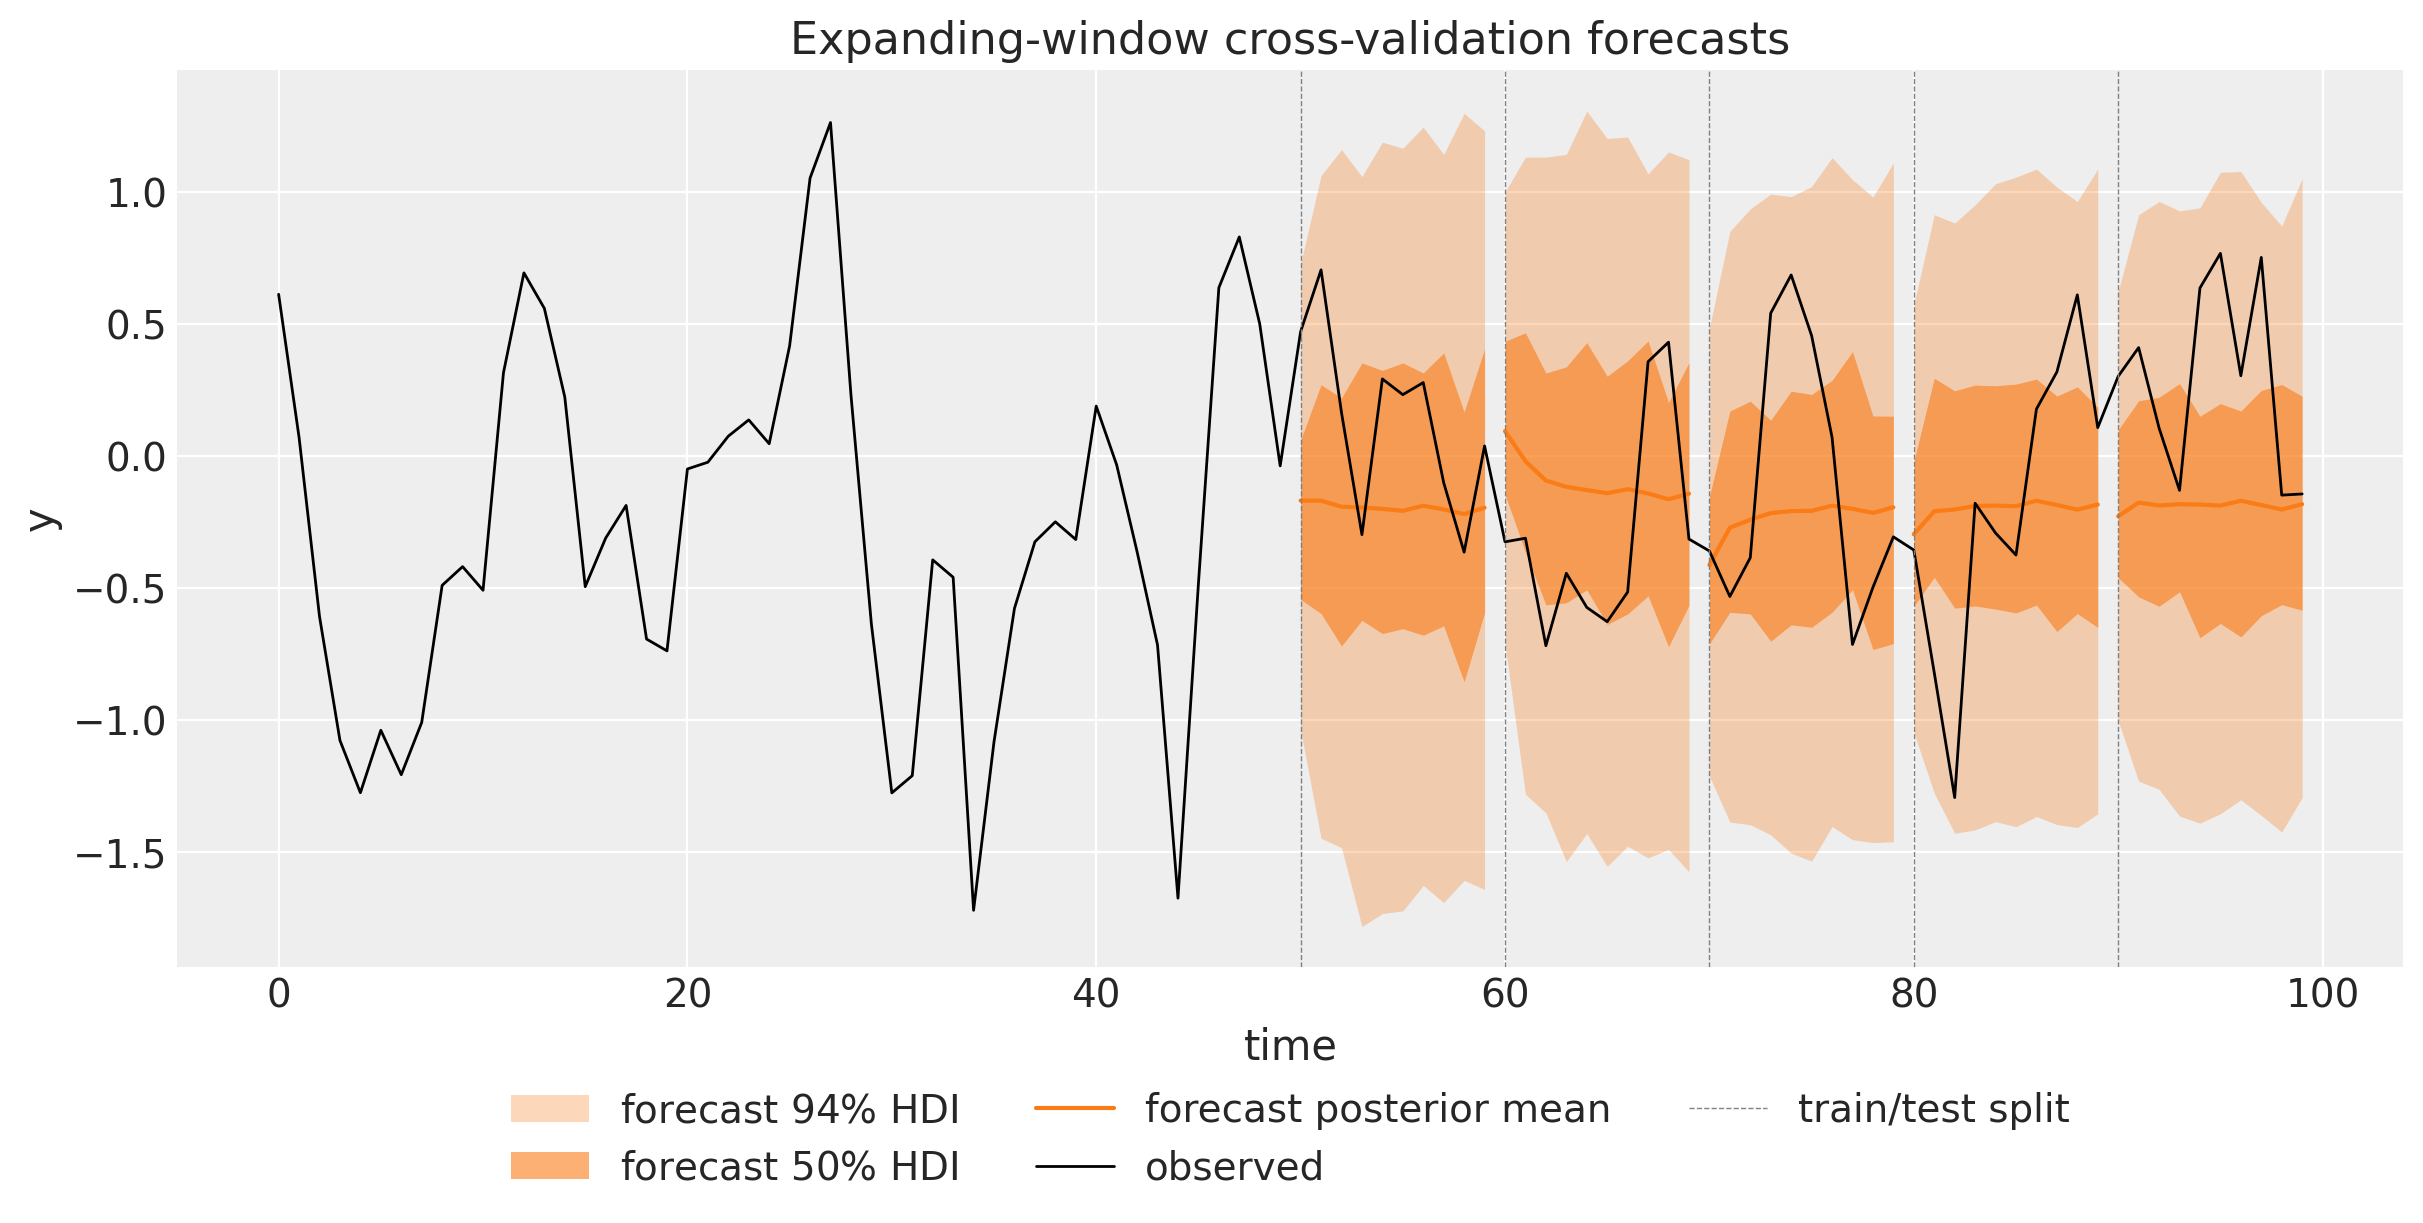

In [12]:
pc = None
for r in results:
    prediction = r.prediction
    if prediction is None:  # keep_predictions=True guarantees this never triggers
        continue
    fold_time = time[r.t1 : r.t2].astype(float)
    idata_fold = predictions_to_datatree(prediction, fold_time, ["y"], observed=data[r.t1 : r.t2])
    if pc is None:
        pc = az.plot_lm(
            idata_fold,
            y="obs",
            x="t",
            plot_dim="time",
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            point_estimate="mean",
            visuals={
                "ci_band": {"color": "C1"},
                "observed_scatter": False,
                "pe_line": {"color": "C1", "alpha": 1.0, "width": 1.5},
            },
            aes={"alpha": ["prob"]},
            alpha=hdi_alphas,
            figure_kwargs={"figsize": (12, 6)},
        )
        bands = pc.viz["ci_band"]["t"]
        band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
        pe_line = pc.viz["pe_line"]["t"].item()
    else:
        az.plot_lm(
            idata_fold,
            y="obs",
            x="t",
            plot_dim="time",
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            point_estimate="mean",
            visuals={
                "ci_band": {"color": "C1"},
                "observed_scatter": False,
                "pe_line": {"color": "C1", "alpha": 1.0, "width": 1.5},
            },
        )

if pc is None:
    msg = "no folds were plotted"
    raise ValueError(msg)
ax = pc.viz["figure"].item().axes[0]
band_94.set_label(hdi_label(0.94, prefix="forecast "))
band_50.set_label(hdi_label(0.5, prefix="forecast "))
pe_line.set_label("forecast posterior mean")
(obs_line,) = ax.plot(time, np.asarray(y), color="black", lw=1, label="observed")
split_lines = [
    ax.axvline(r.t1, color="gray", ls="--", lw=0.5, label="train/test split") for r in results
]
ax.legend(
    handles=[band_94, band_50, pe_line, obs_line, split_lines[0]],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title="Expanding-window cross-validation forecasts", xlabel="time", ylabel="y");

The bands show textbook ARMA behavior. Within each fold the forecast mean decays toward the unconditional level at the geometric rate $\phi^h$, so with $\phi = 0.4$ the memory of the last observation is essentially gone after two or three steps and the band settles at the *marginal* width of the process. This is not a defect: for a short-memory process, reverting quickly to the stationary distribution is exactly the right forecast, and what cross-validation checks here is that the bands are the right width, in other words that the forecast is calibrated.

### CRPS per fold

The per-fold CRPS quantifies the picture. The in-sample and out-of-sample scores stay close across folds, and neither trends upward as the training window grows, so the model is neither over- nor under-fitting: with only four parameters and a correctly specified model class, even the first fold's $50$ observations pin the predictive distribution down well. The out-of-sample score is a bit noisier, as it is computed from just $10$ observations per fold.

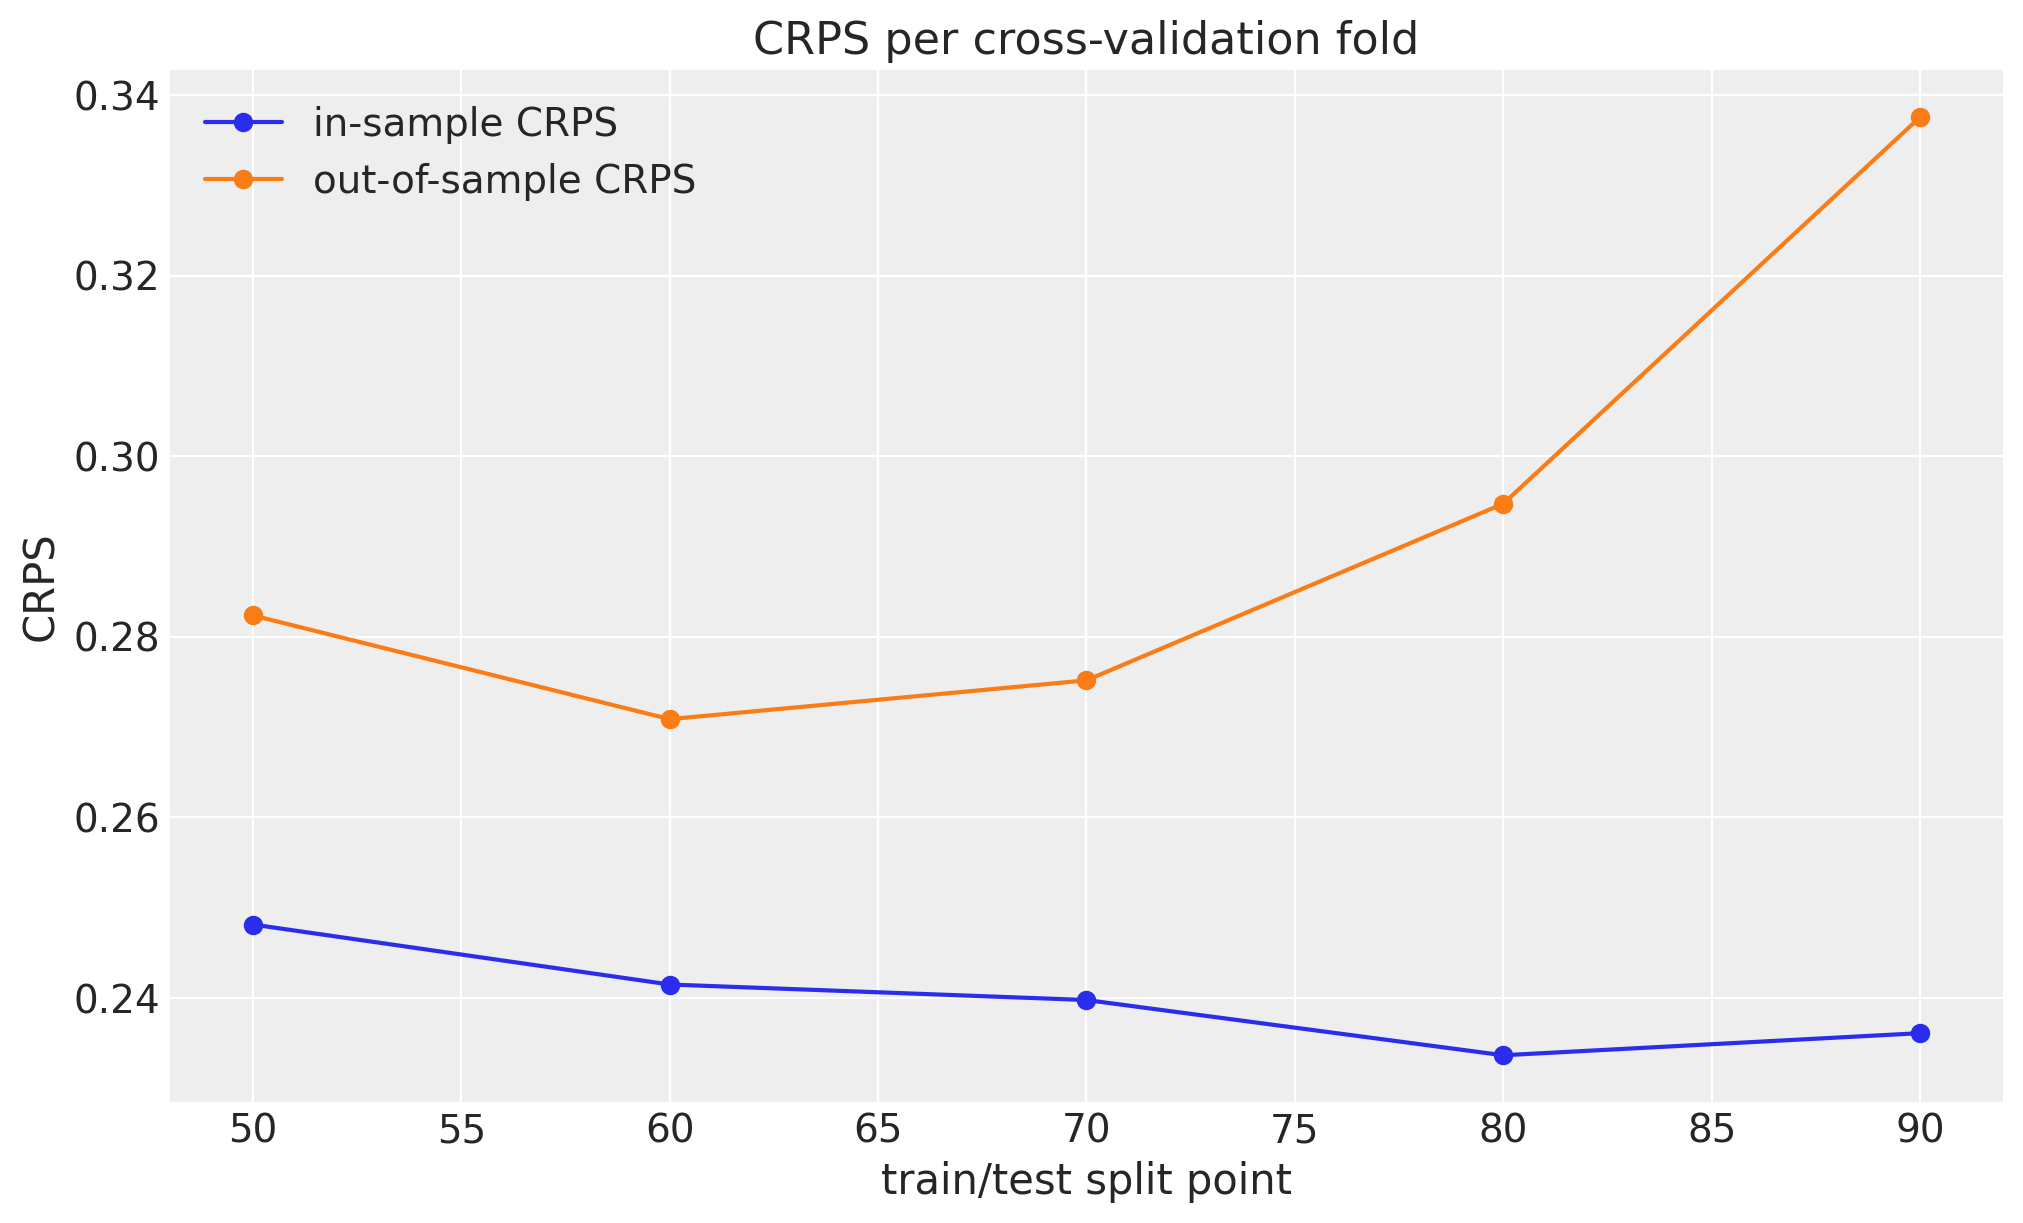

In [13]:
fig, ax = plt.subplots()
ax.plot(split_points, train_crps, "o-", color="C0", label="in-sample CRPS")
ax.plot(split_points, test_crps, "o-", color="C1", label="out-of-sample CRPS")
ax.legend()
ax.set(xlabel="train/test split point", ylabel="CRPS", title="CRPS per cross-validation fold");

### Forecast calibration

Finally we check the coverage: the fraction of held-out observations that fall inside the central $50\%$ and $94\%$ prediction intervals of their fold's forecast. Well-calibrated forecasts should track the dashed nominal levels; points above mean the bands are too wide (under-confident), points below that they are too narrow (over-confident). With only $10$ observations per fold the empirical coverage is grainy (each observation moves it by $0.1$), so some wobble around the nominal levels is expected.

A small caveat: `eval_coverage` measures coverage of the central quantile interval, while the plotted bands are ArviZ HDIs. For the near-symmetric Gaussian predictive here the two nearly coincide, so this is a faithful check of the bands shown above.

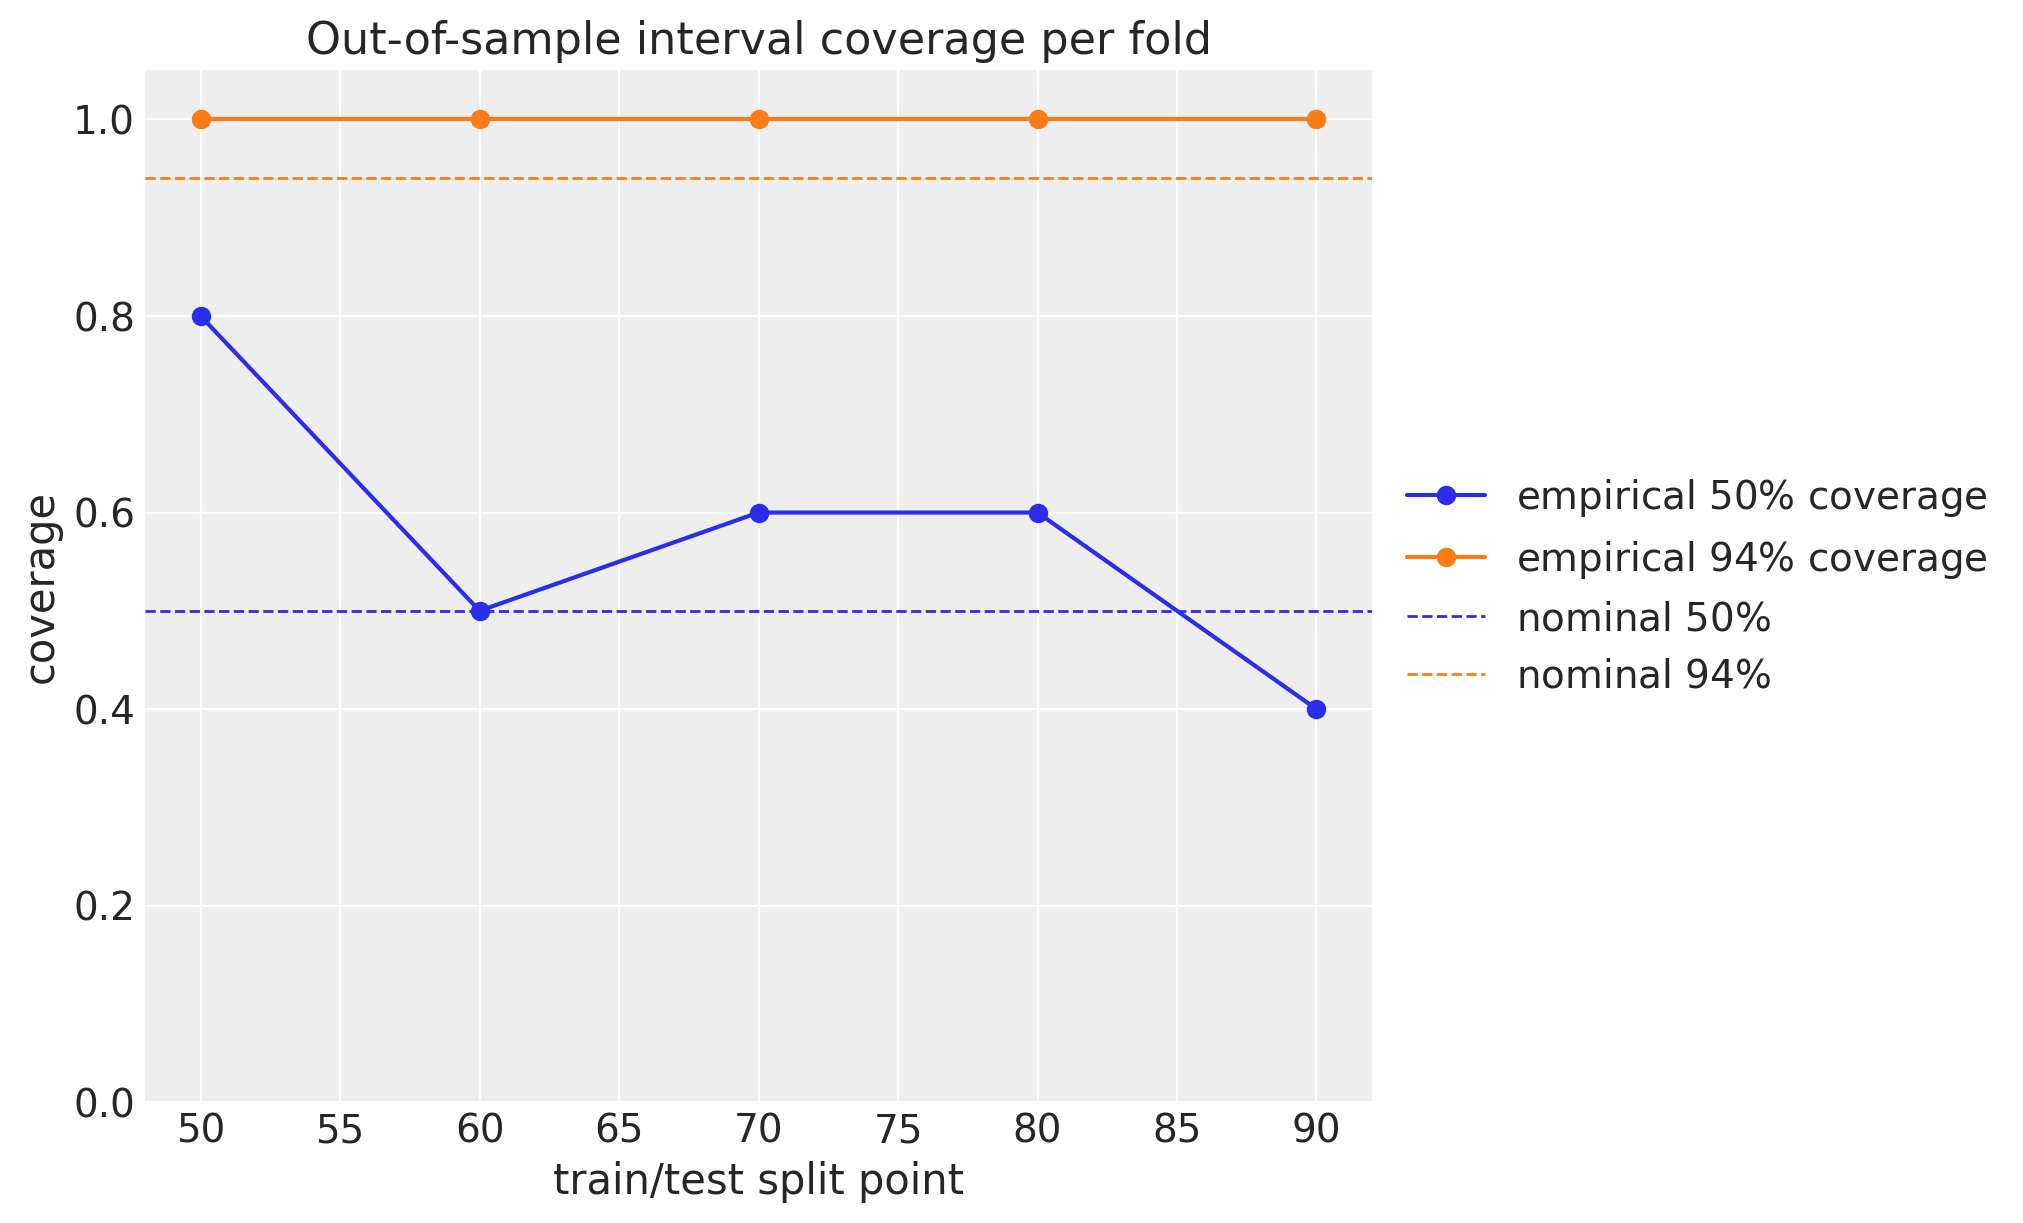

In [14]:
fig, ax = plt.subplots()
ax.plot(split_points, test_cov_50, "o-", color="C0", label=r"empirical $50\%$ coverage")
ax.plot(split_points, test_cov_94, "o-", color="C1", label=r"empirical $94\%$ coverage")
ax.axhline(0.5, color="C0", ls="--", lw=1, label=r"nominal $50\%$")
ax.axhline(0.94, color="C1", ls="--", lw=1, label=r"nominal $94\%$")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(
    xlabel="train/test split point",
    ylabel="coverage",
    title="Out-of-sample interval coverage per fold",
    ylim=(0, 1.05),
);

## References

- Orduz, J. [*Notes on an ARMA(1,1) Model with NumPyro*](https://juanitorduz.github.io/arma_numpyro/). The blog post this notebook ports.
- Hyndman, R. J., & Athanasopoulos, G. (2021). [*Forecasting: Principles and Practice*](https://otexts.com/fpp3/), 3rd edition. Chapter 9: ARIMA models.
- NumPyro documentation: [Example: AR(2) process](https://num.pyro.ai/en/stable/examples/ar2.html).
- Pyro forum: [Lax.scan to implement ARMA(1,1)](https://forum.pyro.ai/t/lax-scan-to-implement-arma-1-1/2518).
- The [exponential smoothing example](https://juanitorduz.github.io/numpyro_forecast/examples/exponential_smoothing_state_space.html) in this documentation, which uses the same functional-model-body pattern for an error-feedback model.
- The [univariate forecasting example](https://juanitorduz.github.io/numpyro_forecast/examples/forecasting_univariate.html) in this documentation, which introduces `backtest` and the per-fold evaluation workflow.